# Player Elo ratings from real match data

This notebook documents, end to end, how we turn the raw `data_test.xlsx` match file into a
per-player Elo rating time series and export it.

**Method.** Player ratings implement Wolf, Schmitt & Schuller (2020), *"A football player rating
system"* (J. Sports Analytics, DOI 10.3233/JSA-200411), formulas (6)-(10):

- **(6)** a team's strength for a match is the *minutes-weighted average* of its line-up;
- **(7)** each player's expected result comes from the classic Elo curve vs. the opposing team;
- **(8)** the actual result is win/draw/loss from the player's personal goal difference while on
  the pitch (`D_Ai`);
- **(9)** the size of the change scales with the goal margin (`|D|^(1/3)`), or with minutes on a
  goalless personal result;
- **(10)** the new rating blends the player's personal and team performance (weights `q` / `1-q`,
  responsiveness `k`).

Ratings follow the **person**: they persist across team changes and seasons.

**Output.** A normalized long table, one row per player *appearance*:
`Player, season, round, team_at, rating, date` (rating = the player's Elo **after** that match).

## 1. Setup
Locate the repo root (so the notebook runs from anywhere) and import the building blocks.

In [1]:
from pathlib import Path
import sys

# Walk up from the notebook until we find the repo root (it contains data_test.xlsx).
root = Path.cwd()
while not (root / "data_test.xlsx").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))
DATA = root / "data_test.xlsx"
print("repo root:", root)

import pandas as pd
import matplotlib.pyplot as plt

from dfg_rating.model import factory
from dfg_rating.model.network.base_network import WhiteNetwork
from dfg_rating.model.rating.player_elo_rating import PlayerELORating

repo root: /home/mgarnica/projects/dfg-rating


## 2. The data, and why it needs shaping
`data_test.xlsx` has one row per match. Line-ups are stored as **parallel per-side lists** and
there is **no round/matchday column** — only timestamps. Three adjustments are needed:

1. **Score:** `home_score_x`/`away_score_x` are the clean integer final scores (the `*_y`
   variants have gaps) — rename them to `home_score`/`away_score`.
2. **Round:** the player rating is a *per-round* series, so we synthesize `round` as the
   chronological match index within each season (1..N by `date`).
3. **Line-ups:** `home_player_list` / `home_minutes_list` / `home_goal_diff_list` (and `away_*`)
   are parsed in "lists" mode; non-player tokens like `red_card_1` are dropped.

In [2]:
raw = pd.read_excel(DATA)
print(raw.shape)
raw[["date", "home_team", "away_team", "home_score_x", "away_score_x", "result",
     "home_player_list", "home_minutes_list", "home_goal_diff_list"]].head(2)

(8775, 50)


,date,home_team,away_team,home_score_x,away_score_x,result,home_player_list,home_minutes_list,home_goal_diff_list
0,2023-07-21 18:00:00,FC Vysočina Jihlava,Slezský FC Opava,2,1,home,"[""Soukup P."", ""Araujo-Wilson J."", ""Farka D."", ...","[90, 89, 77, 68, 90, 90, 90, 90, 90, 68, 90, 2...","[1, 0, -1, -1, 1, 1, 1, 1, 1, -1, 1, 2, 2, 2, 1]"
1,2023-07-21 21:15:00,Torreense,Mafra,1,0,home,[],[],[]


In [3]:
# Shape the frame (same logic as experiments/player_elo_export/run.py).
df = raw.rename(columns={"home_score_x": "home_score", "away_score_x": "away_score"})
df = df.sort_values(["season_id", "date"]).reset_index(drop=True)
df["round"] = df.groupby("season_id").cumcount() + 1
print("matches:", len(df), "| seasons:", df['season_id'].nunique(),
      "| rounds:", df['round'].min(), "-", df['round'].max())

matches: 8775 | seasons: 1 | rounds: 1 - 8775


## 3. Load the network and parse line-ups
The `player-soccer-lists` mapping tells `WhiteNetwork` to read the list columns and build a
player directory (`net.players`). `node1` is the away team, `node2` the home team.

In [4]:
net = WhiteNetwork(data=df, mapping=factory.pre_mappings["player-soccer-lists"])
print("distinct players:", len(net.players))

# Peek at one parsed line-up (home side of the first match).
edge = next(d for _, _, _, d in net.data.edges(keys=True, data=True) if d["round"] == 1)
edge["lineups"]["home"][:3]

Network loaded correctly
distinct players: 11981


[{'player_id': 'Soukup P.',
  'minutes': 90,
  'goal_diff': 1,
  'start': None,
  'end': None},
 {'player_id': 'Araujo-Wilson J.',
  'minutes': 89,
  'goal_diff': 0,
  'start': None,
  'end': None},
 {'player_id': 'Farka D.',
  'minutes': 77,
  'goal_diff': -1,
  'start': None,
  'end': None}]

## 4. Compute player ratings (formulas 6-10)
One chronological pass over all matches. Defaults: `k=32`, `q=0.75`, new players start at 1000.

In [5]:
rating = PlayerELORating(k=32, q=0.75, initial_rating=1000)
net.add_player_rating(rating)
print("rated players:", len(rating.current))

rated players: 11981


## 5. Export — one row per appearance
`export_player_match_ratings` walks every match and emits each player's rating **after** it,
with the team they played for.

In [6]:
out = net.export_player_match_ratings(filename=str(root / "player_ratings.csv"))
print(out.shape)
out.head(8)

(267736, 6)


,Player,season,round,team_at,rating,date
0,A. Jung,14,308,KV Oostende,984.000000,2023-08-13 16:00:00
1,A. Jung,14,497,KV Oostende,967.951144,2023-08-19 20:00:00
2,A. Jung,14,762,KV Oostende,949.715002,2023-08-27 16:00:00
3,A. Jung,14,953,FC Valenciennes,949.965035,2023-09-02 19:00:00
4,A. Jung,14,1196,FC Valenciennes,939.318288,2023-09-16 19:00:00
5,A. Jung,14,1449,FC Valenciennes,940.880373,2023-09-23 19:00:00
6,A. Jung,14,1551,FC Valenciennes,927.033314,2023-09-26 20:45:00
7,A. Jung,14,2269,FC Valenciennes,919.171537,2023-10-21 19:00:00


## 6. Worked example — a player's rating trajectory
Pick a player with a single club (clean career line) and plot the familiar Elo "staircase".

In [7]:
# Choose a frequently-appearing player who only ever played for one team.
by_player = out.groupby("Player")
single_club = by_player["team_at"].nunique()
counts = by_player.size()
candidates = counts[(single_club == 1) & (counts >= 20)].sort_values(ascending=False)
player = candidates.index[0]
sub = out[out.Player == player].sort_values(["season", "round"]).reset_index(drop=True)
print(f"{player} — {len(sub)} appearances for {sub['team_at'].iloc[0]}")
sub.head()

De Smet L. — 58 appearances for FC Brügge U23


,Player,season,round,team_at,rating,date
0,De Smet L.,14,228,FC Brügge U23,1016.000000,2023-08-12 16:00:00
1,De Smet L.,14,401,FC Brügge U23,999.924948,2023-08-18 20:00:00
2,De Smet L.,14,621,FC Brügge U23,1025.013832,2023-08-25 20:00:00
3,De Smet L.,14,621,FC Brügge U23,1025.013832,2023-08-25 20:00:00
4,De Smet L.,14,1004,FC Brügge U23,1012.797780,2023-09-03 16:00:00


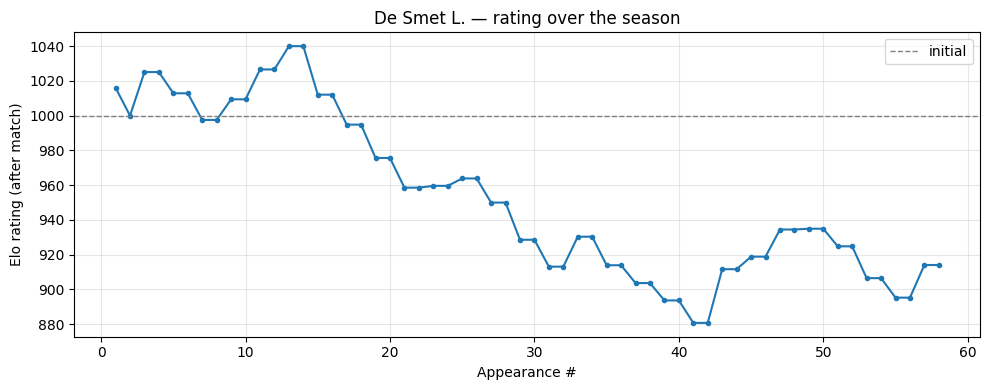

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(sub) + 1), sub["rating"], marker="o", ms=3)
plt.axhline(1000, color="grey", ls="--", lw=1, label="initial")
plt.xlabel("Appearance #")
plt.ylabel("Elo rating (after match)")
plt.title(f"{player} — rating over the season")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

## 7. Caveats

- **Player identity is the name.** The source has no player IDs, so each distinct name is one
  player. Abbreviated names (e.g. `"Camara M."`) collapse several real players into one — such a
  "player" can appear for several clubs on the same day. Disambiguation needs a real player ID.
- **Round = chronological match index.** With a single season in this file, `round` runs
  1..N across the whole season by kickoff time. Matches in different competitions
  (National/International/Cup) share the season, so the sequence is by date, not by league round.
- **`rating` is post-match.** Each row is the player's rating *after* that appearance; a player's
  first row already reflects their first match.